### This notebook demonstrates the post-analysis and visualisation of the PRAS results

In [1]:
import sys
import os

import calendar
import pandas as pd
import matplotlib.pyplot as plt
import time
import datetime as datetime
sys.path.append("src")
import numpy as np
from utility import get_shortfall_data, plot_std_error, load_scenario_data
from utility import load_eue_shortfall, get_all_info, reg_load_gen
from utility import plot_yearly_rlg_v1, seasonal_ppmm_stats,get_data_simu 
from utility import flow_result, plot_flow, plot_EUE_lgs

area_code_region = {1:"NNSW", 2:"CNSW", 3:"SNW", 4:"SNSW", 5:"WNV",
                        6:"MEL", 7:"SEV",  8:"NQ", 9:"CQ", 10:"GG",
                        11:"SQ", 12:"NSA", 13:"CSA", 14:"SESA", 15:"TAS"} 

IDIR = os.path.join(os.getcwd(), "../data", "pras_metrics_output", "shortfall_data")
figsize = (25,10)

In [2]:
def load_shortfall_error_data(scenario, IDIR):
    scen_DIR = os.path.join(IDIR, scenario)
    if scenario == "MT":
        date_run = "27-Mar-26-21-14-11"
    elif scenario == "ST":
        date_run = "27-Mar-26-21-0-57"
    elif scenario == "LT":
        date_run = "27-Mar-26-20-35-52"
        SDIR = os.path.join(os.getcwd(), "../../../../junk", "ISP_DATA")
        scen_DIR = os.path.join(SDIR, scenario)
    elif scenario == "SUM_ED":
        date_run = "14-Mar-26-15-27-7"
  
    data_file = os.path.join(scen_DIR, date_run, "pras_results.json")
    lole_mean, lole_std, eue_mean, eue_std, neue_mean, neue_std, shortfall_data = get_shortfall_data(data_file, area_code_region)
    error_dict = {"lole_mean":lole_mean, "lole_std":lole_std,
             "eue_mean":eue_mean,"eue_std":eue_std,"neue_mean":neue_mean,
             "neue_std":neue_std,"shortfall_data":shortfall_data}
    return error_dict, shortfall_data
    

In [3]:
scenario = "LT"
print("Scenario chosen: ", scenario)
error_dict, shortfall_data = load_shortfall_error_data(scenario, IDIR)

Scenario chosen:  LT


Scenario:  ST


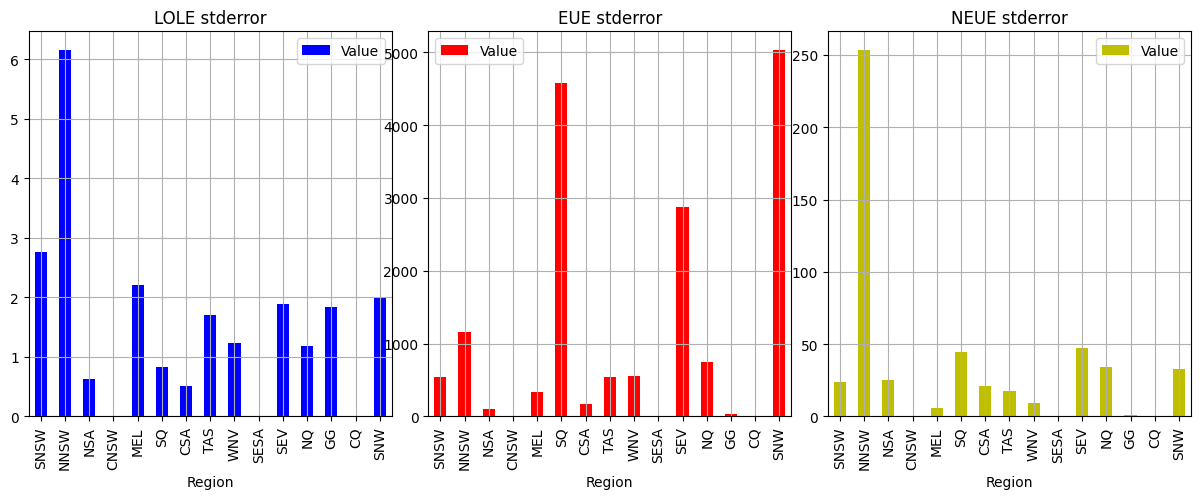

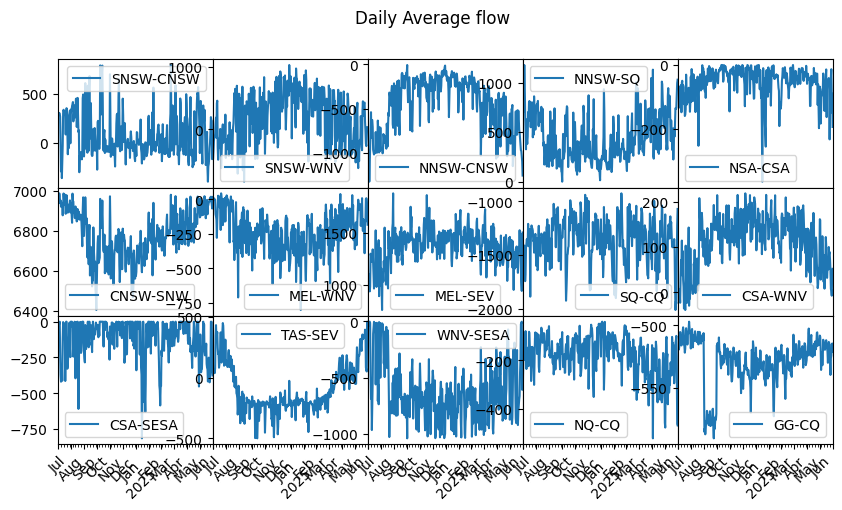

In [19]:
print("Scenario: ", scenario)
plot_std_error(error_dict)
mean_flow, std_flow = load_scenario_data(scenario, IDIR, area_code_region)

Scenario:  MT


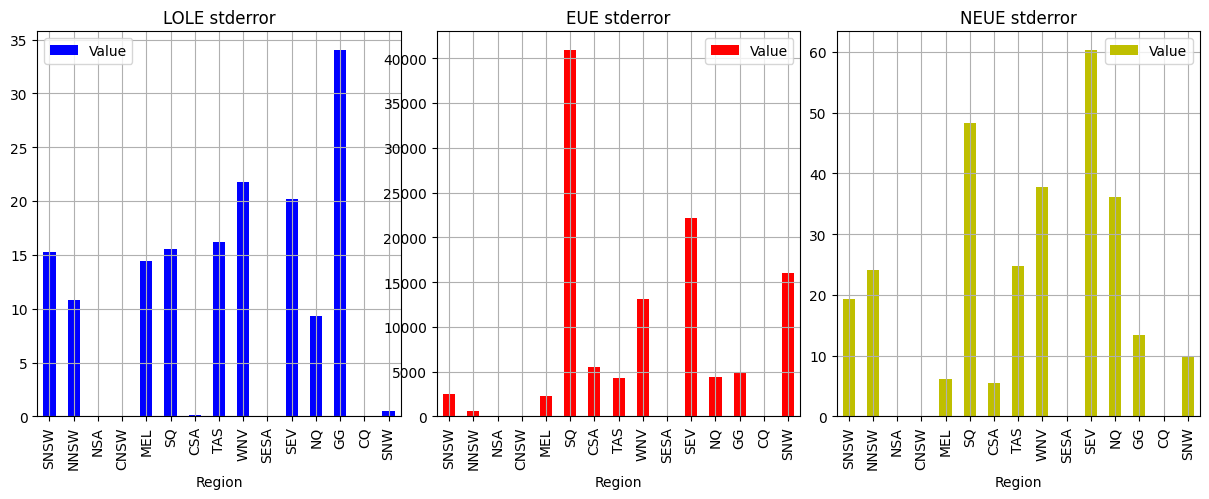

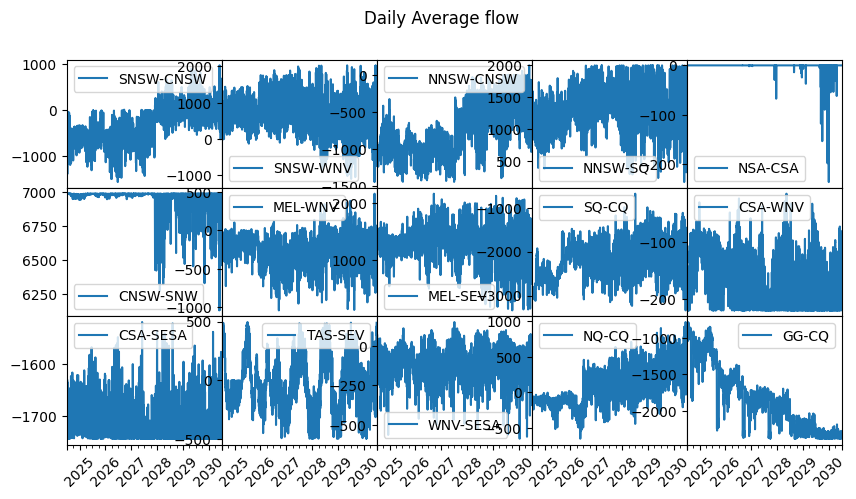

In [21]:
print("Scenario: ", scenario)
plot_std_error(error_dict)
mean_flow, std_flow = load_scenario_data(scenario, IDIR, area_code_region)

Scenario:  LT


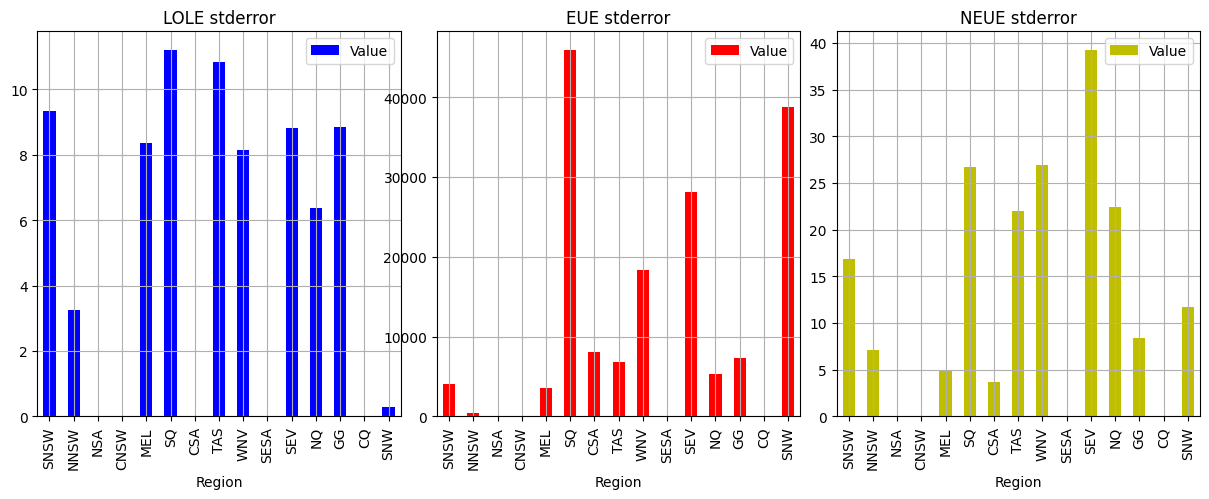

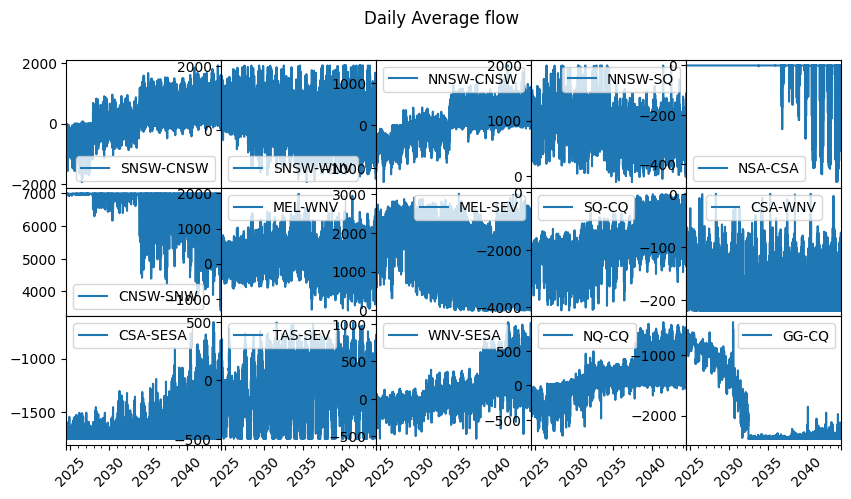

In [24]:
print("Scenario: ", scenario)
plot_std_error(error_dict)
mean_flow, std_flow = load_scenario_data(scenario, IDIR, area_code_region)

scenario:  ST


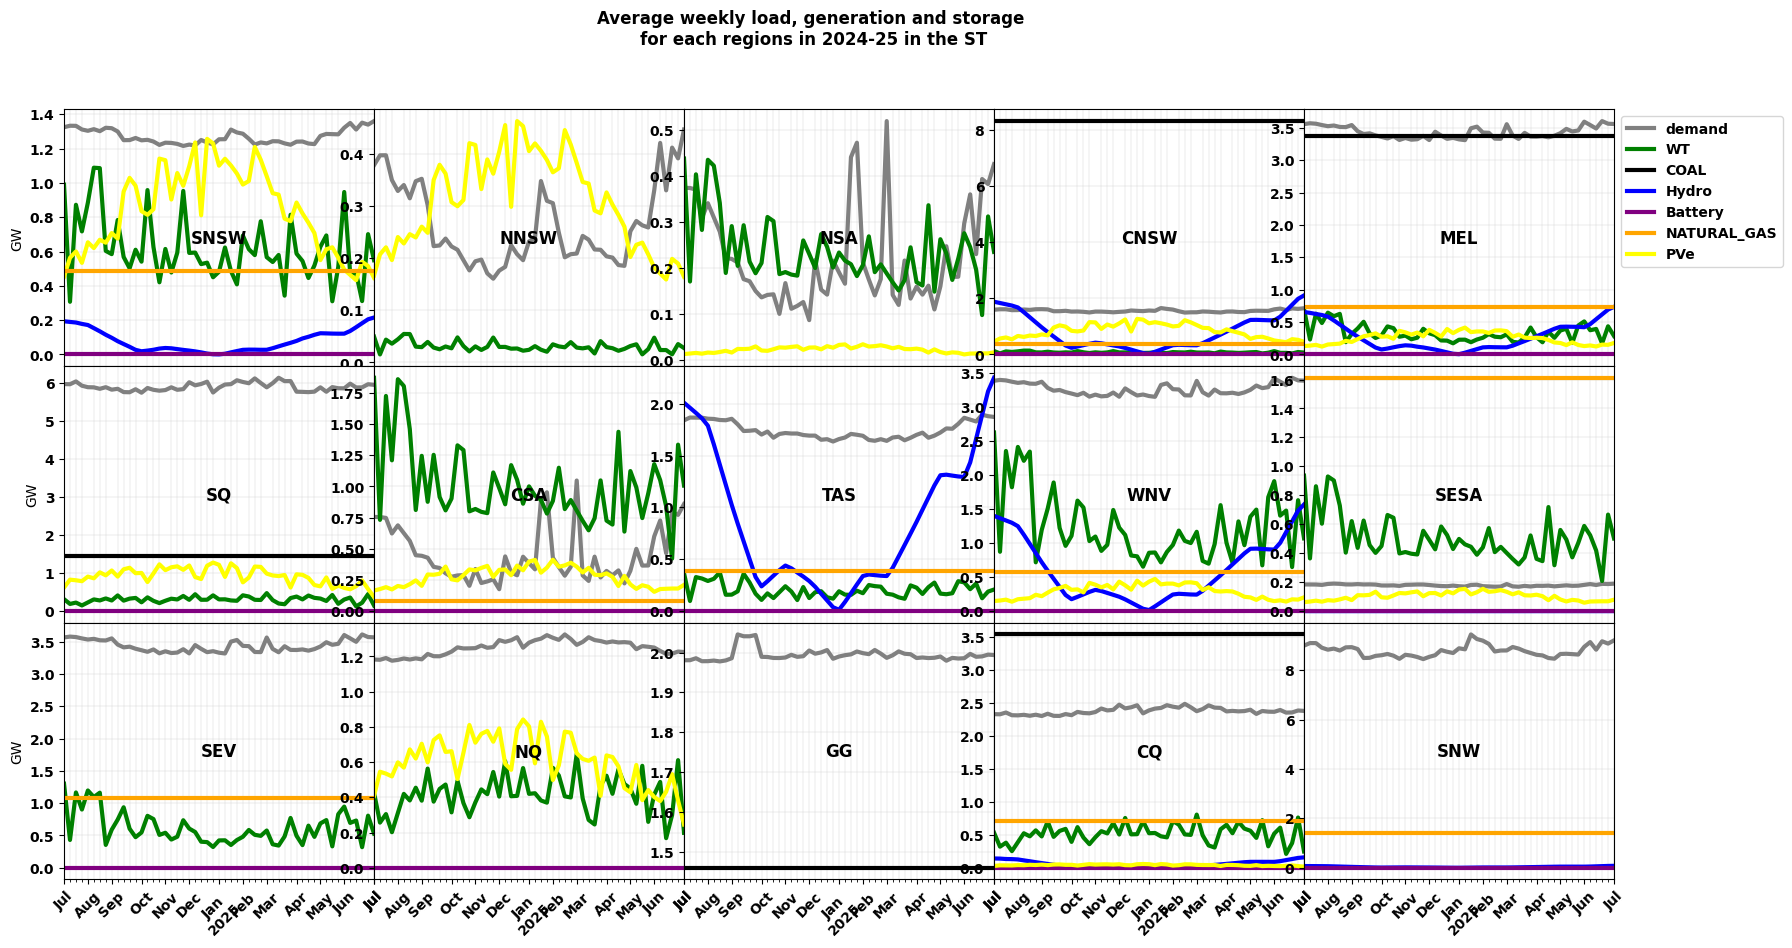

In [72]:
print("scenario: ", scenario)
resample = "weekly"
load_gens_simu = get_data_simu(shortfall_data)
plot_yearly_rlg_v1(load_gens_simu, shortfall_data, 
                   resample, scenario)

scenario:  MT


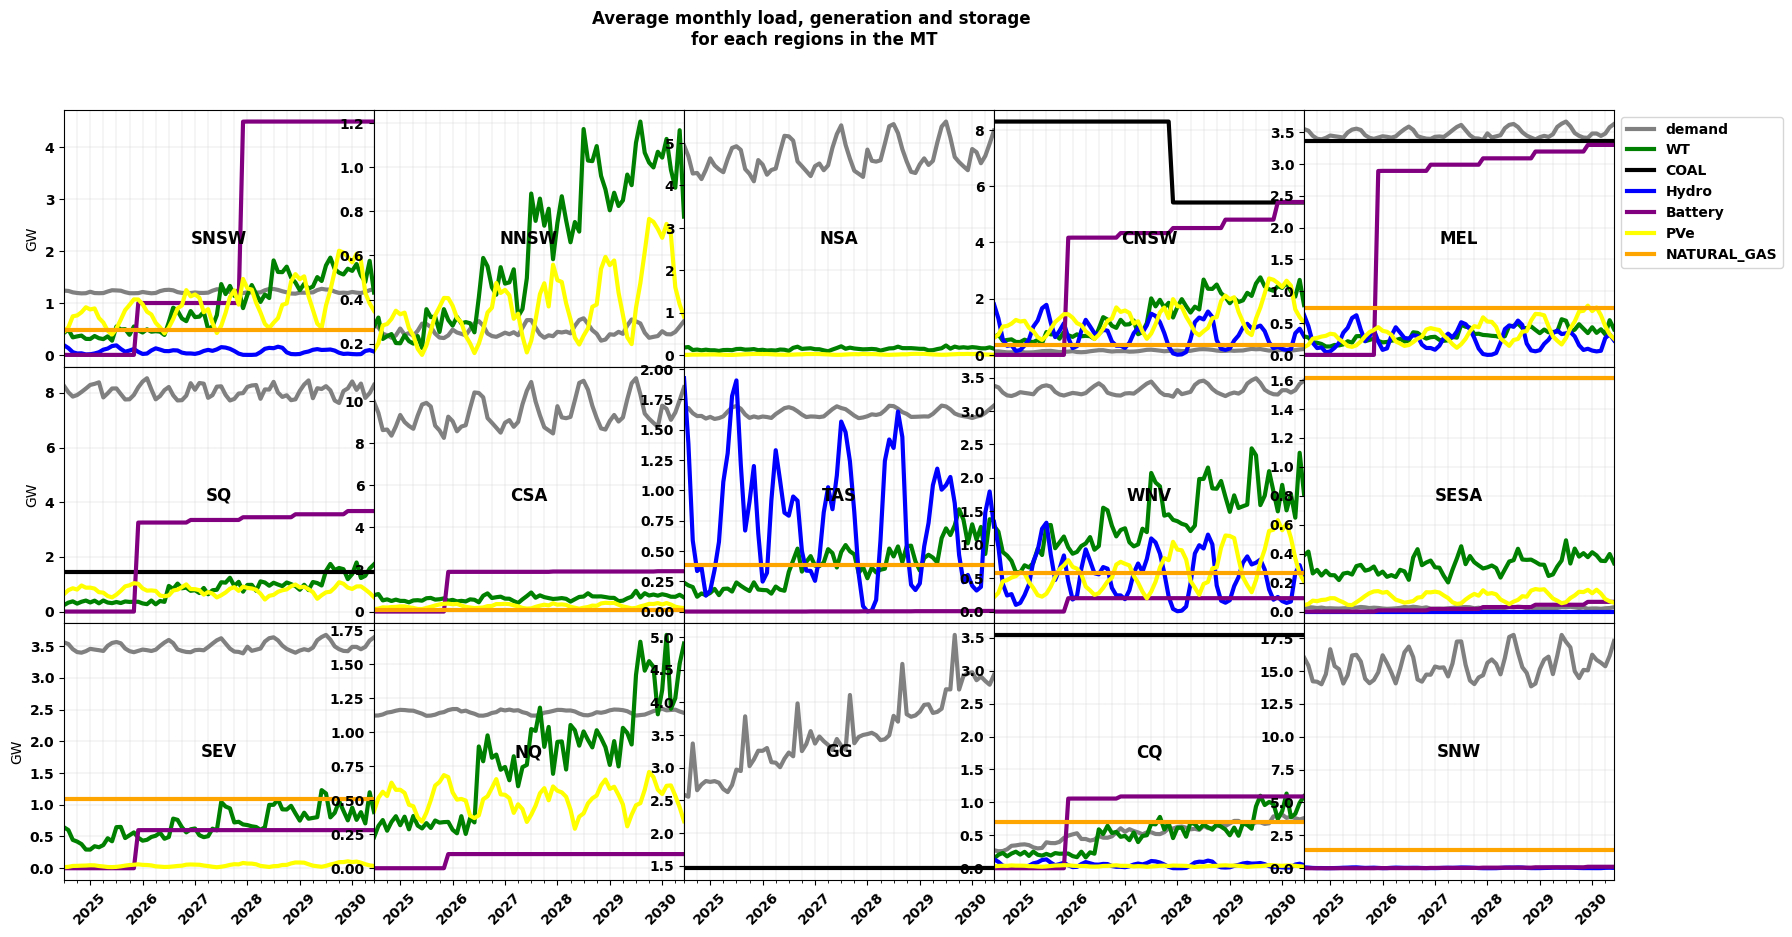

In [70]:
print("scenario: ", scenario)
resample="monthly"
load_gens_simu = get_data_simu(shortfall_data)
plot_yearly_rlg_v1(load_gens_simu, shortfall_data, resample, scenario)

scenario:  LT


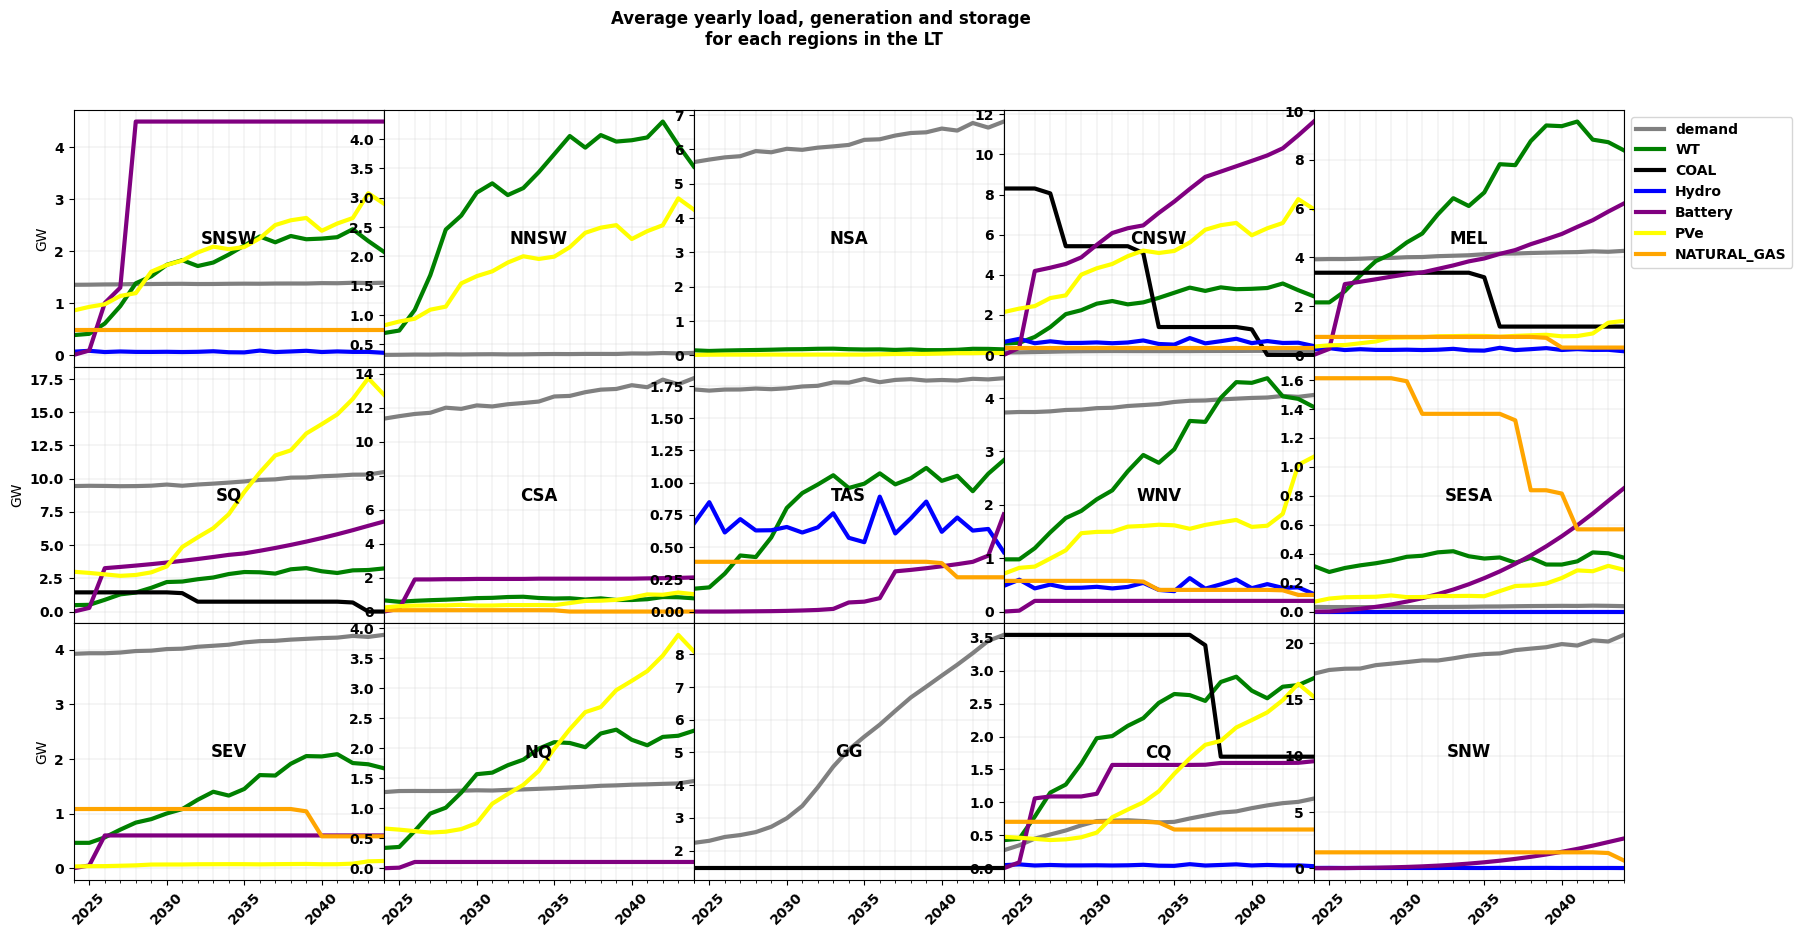

In [68]:
print("scenario: ", scenario)
resample="yearly"
load_gens_simu = get_data_simu(shortfall_data)
plot_yearly_rlg_v1(load_gens_simu, shortfall_data, resample, scenario)

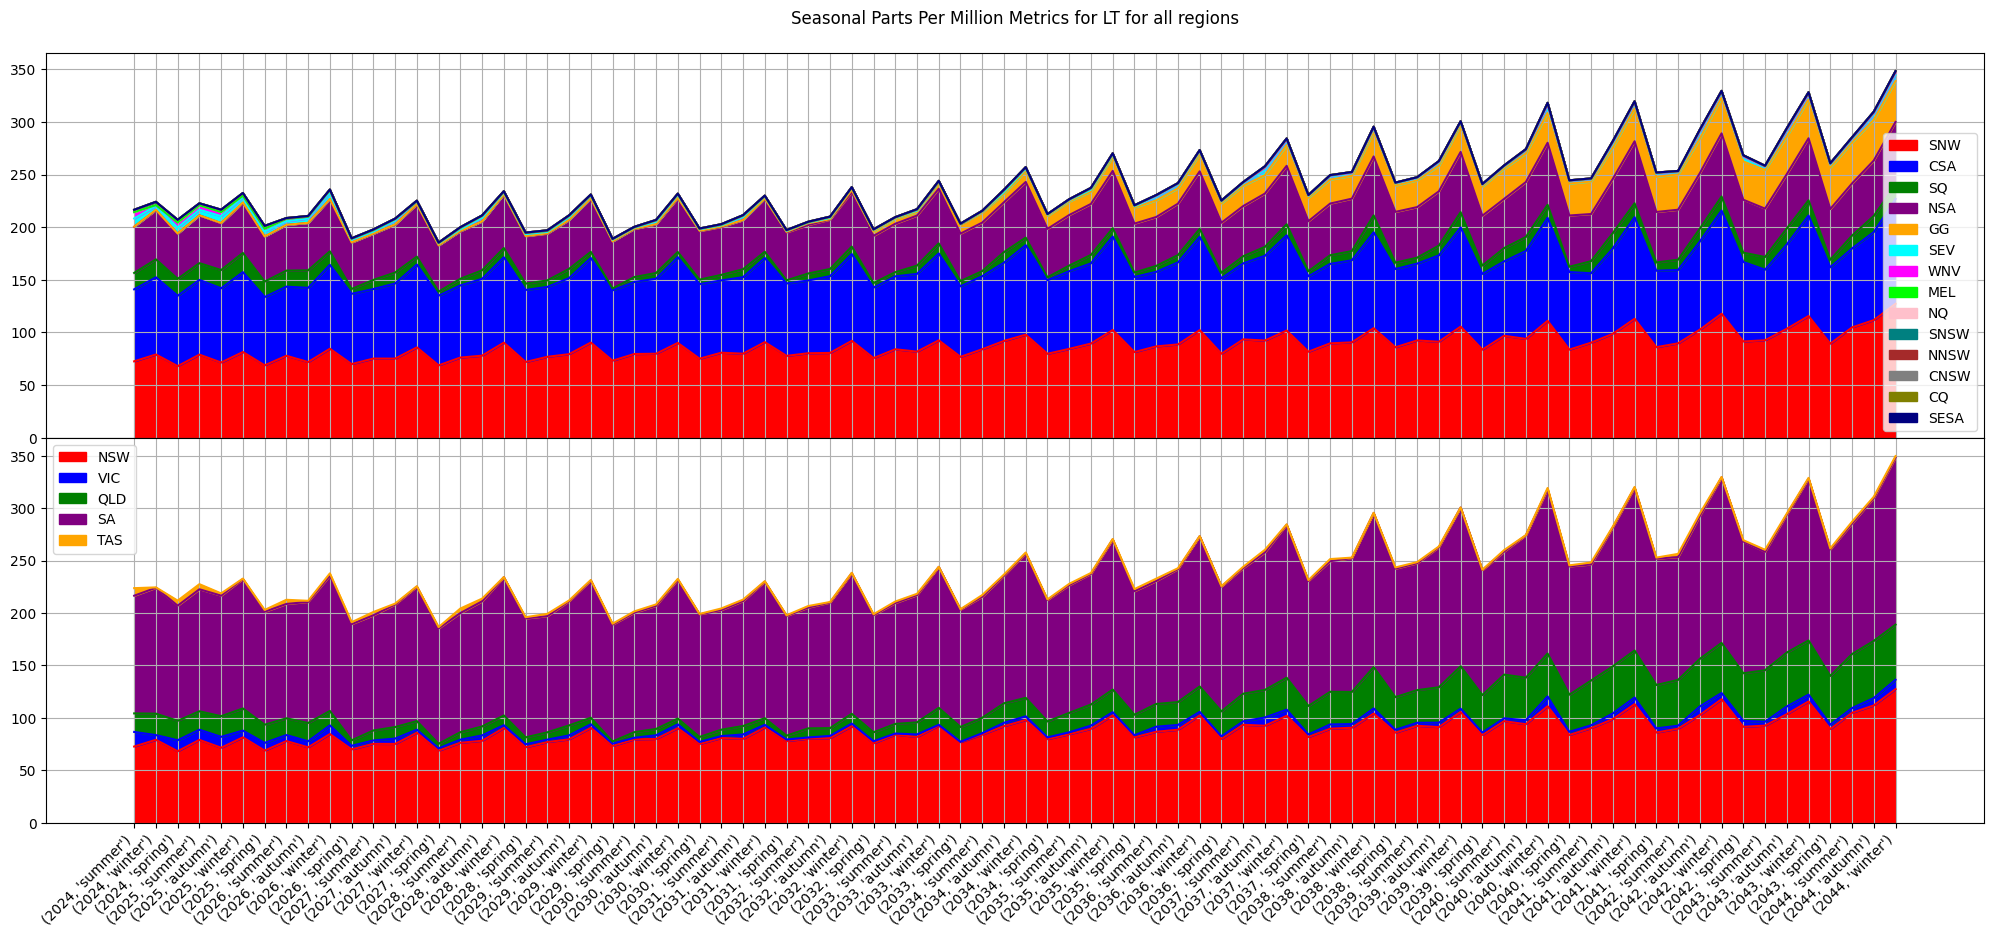

In [5]:
seasonal_data, system_load = seasonal_ppmm_stats(shortfall_data, area_code_region, 
                                                 scenario, IDIR, figsize)

### For any EUE analysis, use ST or MT scenarios for any meaningful study
* Select target region
* select start and end date


In [33]:

#print("Scenario: ", scenario, " target region: ", target_region)


Scenario chosen:  MT


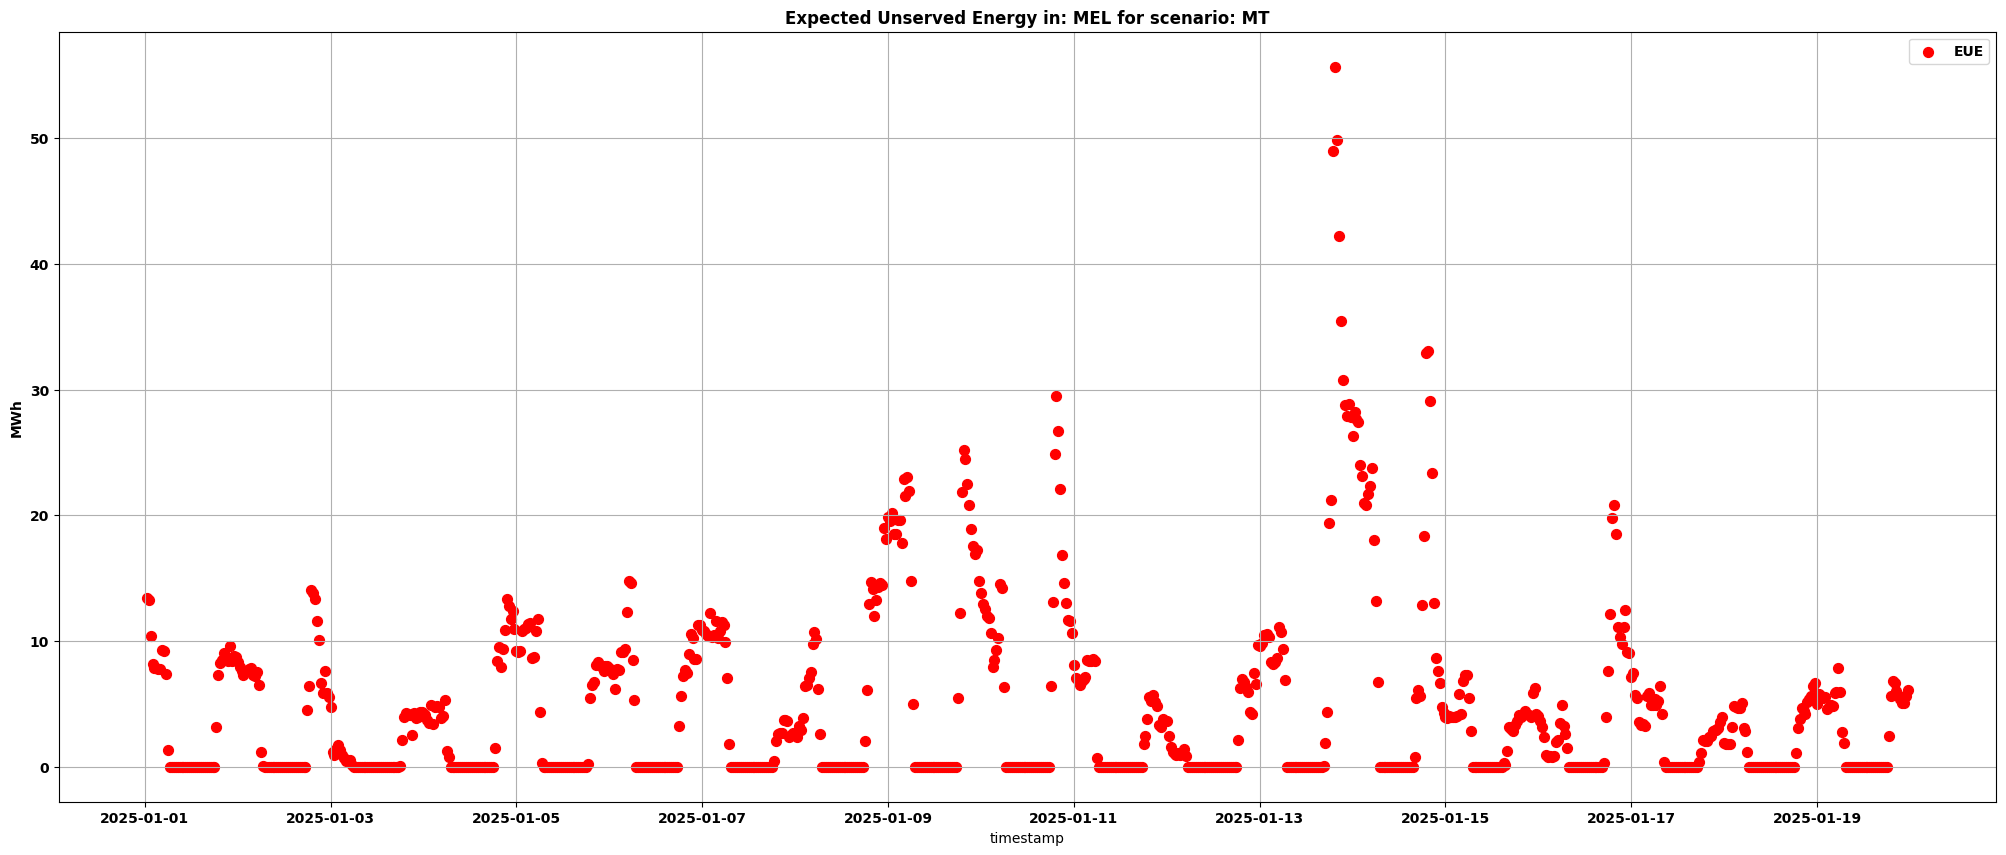

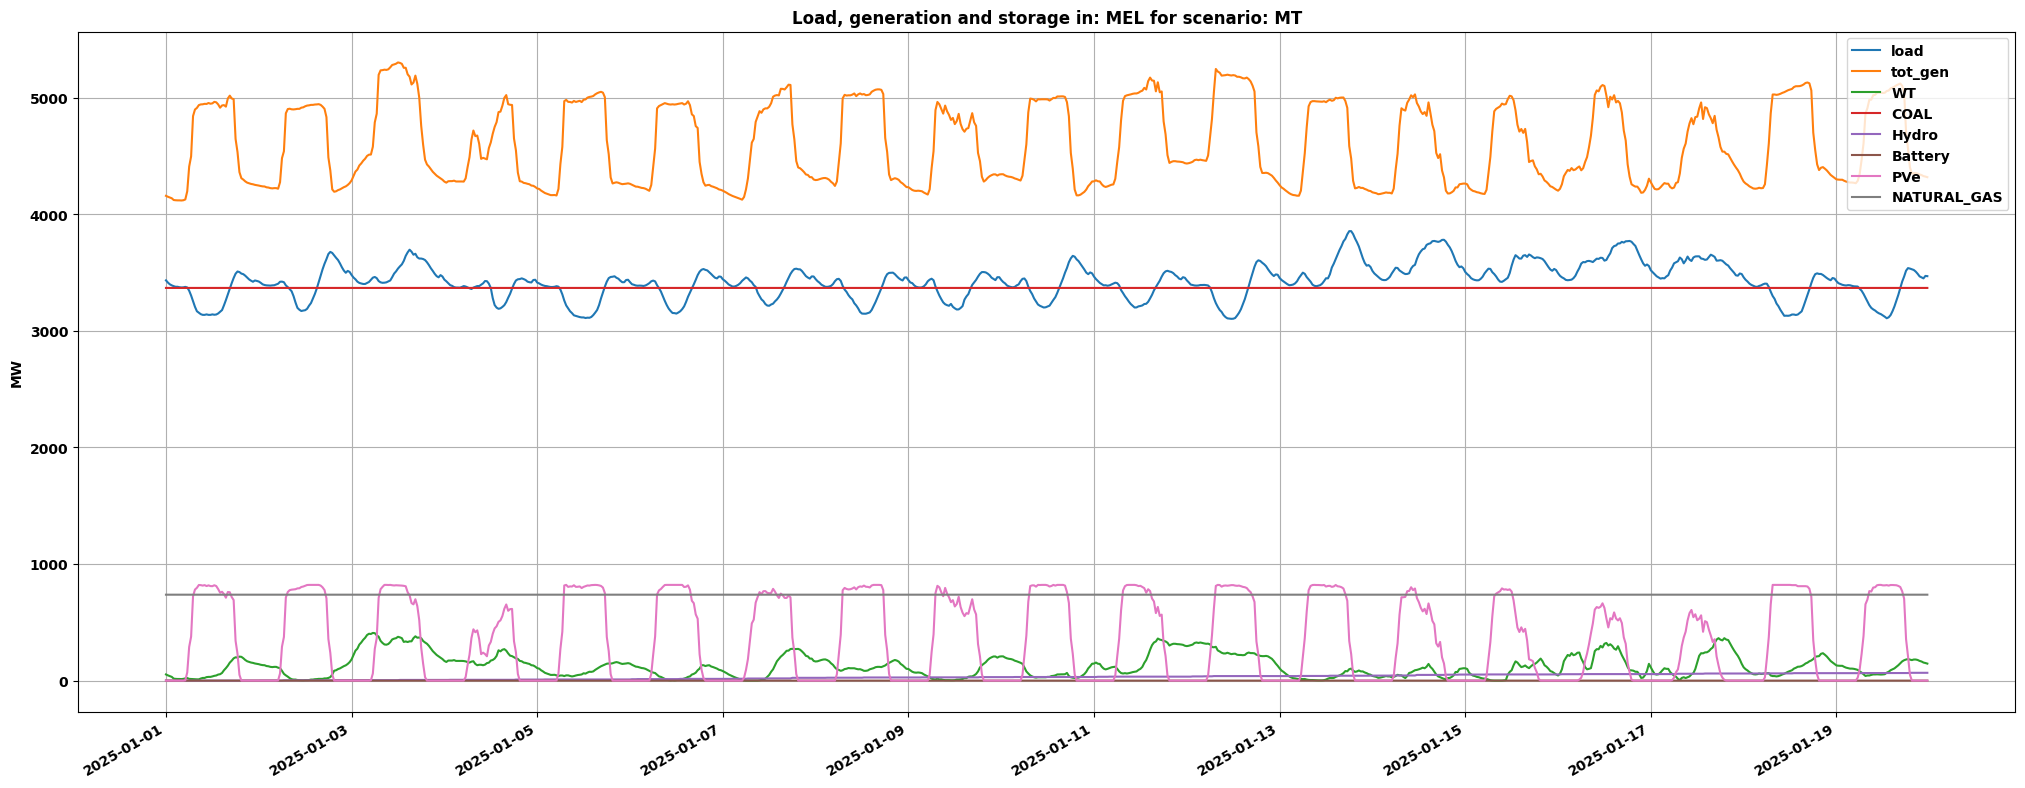

In [3]:
scenario = "MT"
target_region = "MEL"
st_date = '2025-01-1'
en_date = '2025-01-20'

print("Scenario chosen: ", scenario)
error_dict, shortfall_data = load_shortfall_error_data(scenario, IDIR)
plot_EUE_lgs(target_region, st_date, en_date, 
             shortfall_data, area_code_region, 
             scenario, IDIR, figsize)

In [10]:
# available battery in the regions [13,  6, 11,  4,  8,  9,  2,  5,  7]
#flow_for = flow_result(scenario, area_code_region)
#max_EUE = find_max_eue_regions(area_code_region, eue_df)
#print("Maximum Expected Unserved Energy detected :\n", max_EUE)
#print("flow name available for: ", flow_for.columns.tolist())


### The following Flow names are available; the target region will search all available Flow names. 

'SNSW-CNSW_mean_flow',
 'SNSW-WNV_mean_flow',
 'NNSW-CNSW_mean_flow',
 'NNSW-SQ_mean_flow',
 'NSA-CSA_mean_flow',
 'CNSW-SNW_mean_flow',
 'MEL-WNV_mean_flow',
 'MEL-SEV_mean_flow',
 'SQ-CQ_mean_flow',
 'CSA-WNV_mean_flow',
 'CSA-SESA_mean_flow',
 'TAS-SEV_mean_flow',
 'WNV-SESA_mean_flow',
 'NQ-CQ_mean_flow',
 'GG-CQ_mean_flow'


In [4]:
flow_for = flow_result(scenario, area_code_region, IDIR)

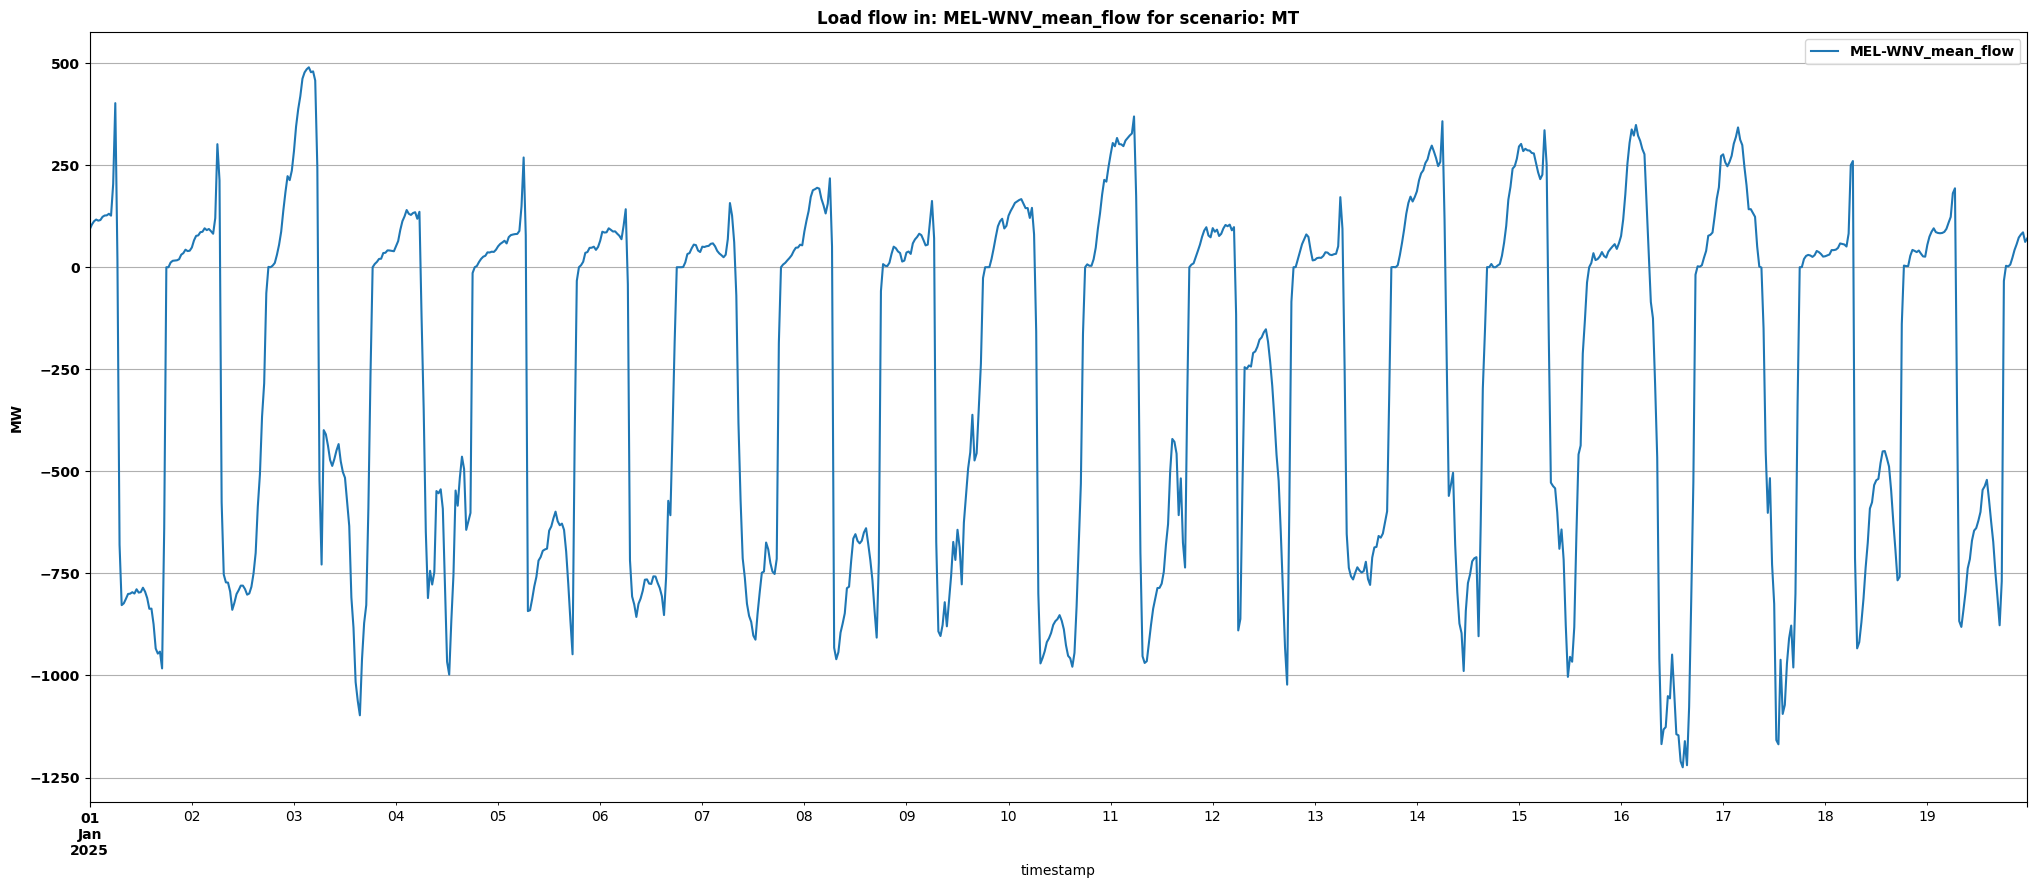

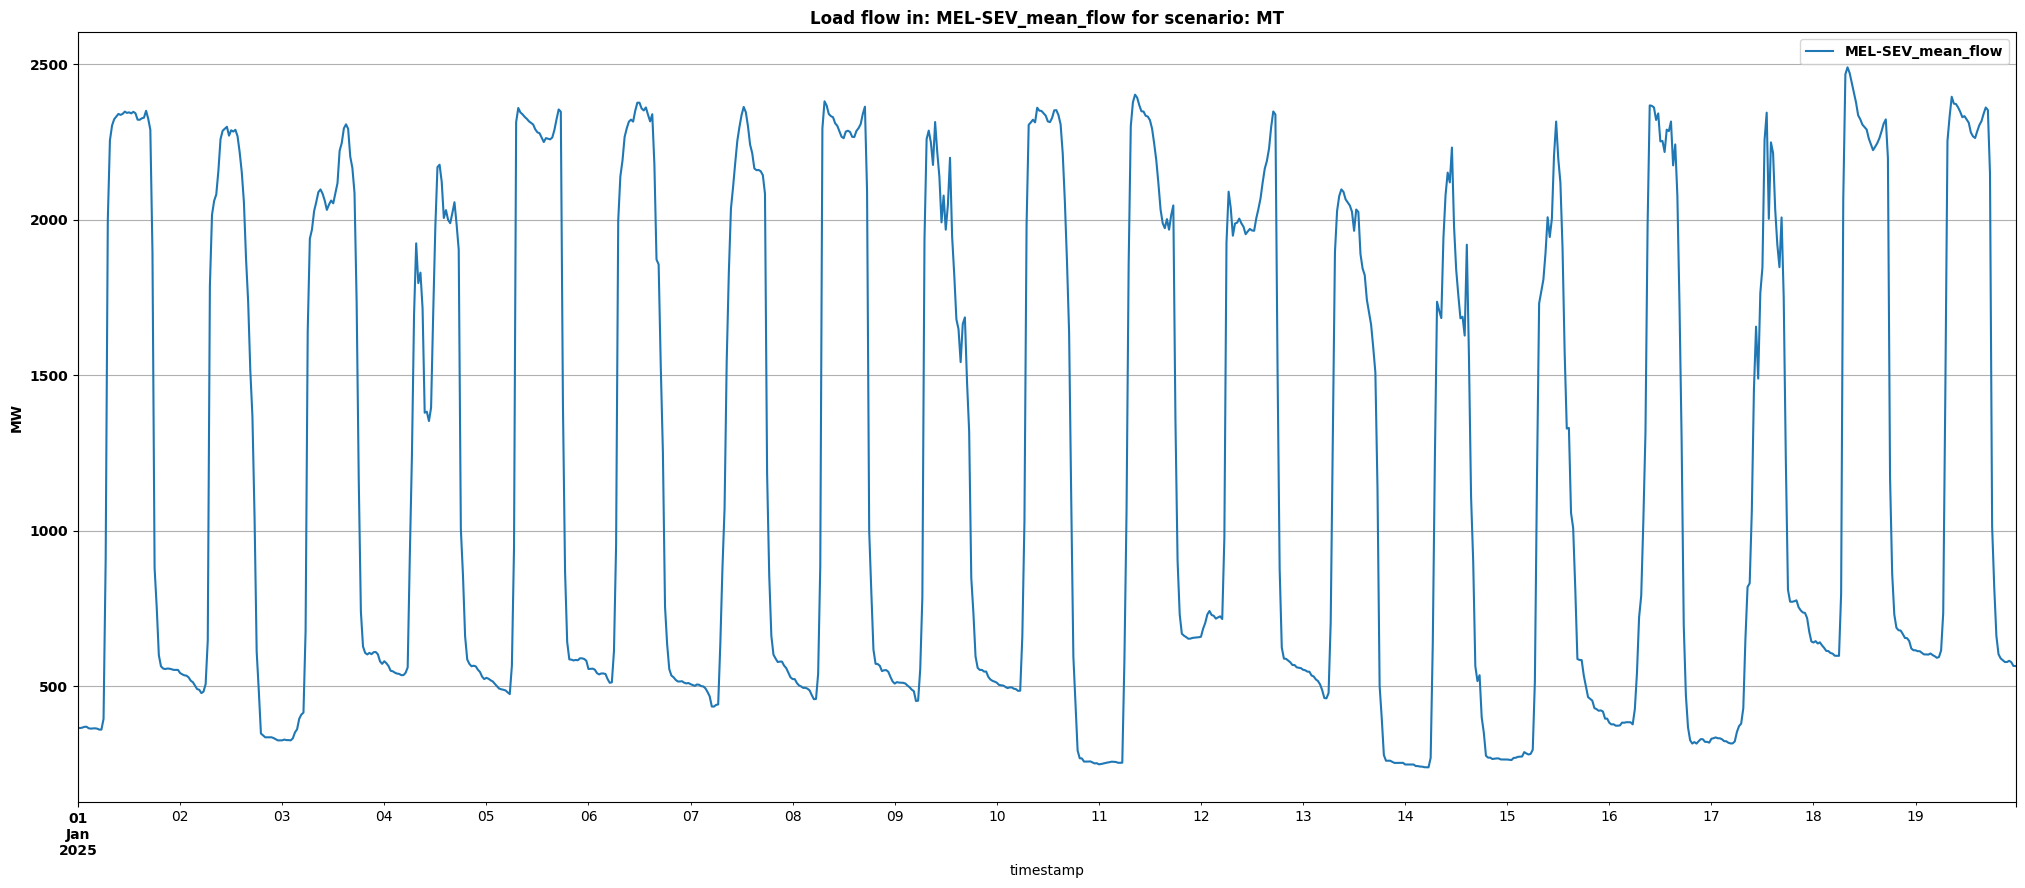

In [6]:
plot_flow(target_region, flow_for, st_date, en_date, scenario, figsize)